# Titanic Survival — Part 2: Logistic Regression from Scratch

In Part 1 we trained a logistic-regression classifier with scikit-learn. In Part 2 we re-train the **same model on the same features and target** — but using only NumPy. The goal is to build intuition for what `LogisticRegression().fit()` actually does under the hood.

We will:
1. Load the cleaned dataset produced by [`titanic_survival_part_1a.ipynb`](titanic_survival_part_1a.ipynb).
2. Split, then standardize the features by hand.
3. Walk through the math: sigmoid, binary cross-entropy, gradients, gradient descent.
4. Implement each component as a separate function.
5. Train the model and track the loss over iterations.
6. Evaluate on the test set and verify against scikit-learn.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CLEAN_PATH = "../data/titanic_clean.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_ITER = 1000
LEARNING_RATE = 0.1

## 1. Load the cleaned dataset

We reuse `data/titanic_clean.csv`, which Part 1a already deduplicated, floored `age` to integer years, replaced `family_size` with the binary `family_size_lt4`, and dropped the redundant `3rd_class` and the unused `fare` columns. If the file does not exist yet, run Part 1a first.

In [2]:
clean = pd.read_csv(CLEAN_PATH)

TARGET = "survived"
FEATURES = [c for c in clean.columns if c != TARGET]

print(f"Shape:    {clean.shape}")
print(f"Features: {FEATURES}")
print(f"Target:   {TARGET}")
clean.head()

Shape:    (817, 6)
Features: ['sex', 'age', '1st_class', '2nd_class', 'family_size_lt4']
Target:   survived


,sex,age,1st_class,2nd_class,survived,family_size_lt4
0,1,22,0,0,0,1
1,0,38,1,0,1,1
2,0,26,0,0,1,1
3,0,35,1,0,1,1
4,1,35,0,0,0,1


## 2. Train/test split and standardization

We use the **same split** as Part 1b — stratified on the target with `random_state=42` and `test_size=0.2` — so the two notebooks are directly comparable.

In [3]:
X = clean[FEATURES]
y = clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train = X_train.to_numpy(dtype=float)
X_test = X_test.to_numpy(dtype=float)
y_train = y_train.to_numpy(dtype=float)
y_test = y_test.to_numpy(dtype=float)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train survival rate: {y_train.mean():.2%}")
print(f"Test  survival rate: {y_test.mean():.2%}")

Train: (653, 5), Test: (164, 5)
Train survival rate: 40.43%
Test  survival rate: 40.24%


Standardization is part of the data path, not part of the algorithm we are reimplementing, so it is fine to compute the mean/std with NumPy directly. Gradient descent converges much faster when features are on a similar scale. We standardize each feature to have zero mean and unit variance:

$$
x_j^{\prime} = \frac{x_j - \mu_j}{\sigma_j}
$$

We fit the statistics on the **training set only** and apply them to both sets
to avoid data leakage.

In [4]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1.0

X_train_s = (X_train - mu) / sigma
X_test_s = (X_test - mu) / sigma

print(f"Train mean (should be ~0): {X_train_s.mean(axis=0).round(4)}")
print(f"Train std  (should be ~1): {X_train_s.std(axis=0).round(4)}")

Train mean (should be ~0): [-0. -0. -0. -0.  0.]
Train std  (should be ~1): [1. 1. 1. 1. 1.]


## 3. Mathematical background

### 3.1 The sigmoid (logistic) function

We model the probability that a passenger survived as the sigmoid of a linear combination of their features:

$$
\sigma(z) = \frac{1}{1 + e^{-z}},
\qquad
z = \mathbf{w}^\top \mathbf{x} + b = \sum_{j=1}^{d} w_j x_j + b
$$

Here $\mathbf{w} \in \mathbb{R}^d$ is the weight vector, $b \in \mathbb{R}$ is the bias (intercept), and $d$ is the number of features.

The sigmoid maps any real number to $(0, 1)$. Large positive logits go to ~1, large negative logits go to ~0, and $z = 0$ maps exactly to 0.5 — the natural decision boundary. The predicted probability is therefore

$$
\hat{y} = P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b).
$$

### 3.2 Binary cross-entropy loss

We measure how well the model fits the training data with the **binary cross-entropy** (log loss), averaged over $n$ samples:

$$
\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n}
\left[
  y^{(i)} \ln\!\big(\hat{y}^{(i)}\big)
  + \big(1 - y^{(i)}\big) \ln\!\big(1 - \hat{y}^{(i)}\big)
\right]
$$

BCE penalizes confident-and-wrong predictions much more than uncertain ones. The loss is **convex** in $\mathbf{w}$ and $b$, so gradient descent is guaranteed to find the global minimum.

### 3.3 Gradient derivation

Using the chain rule and the identity $\sigma'(z) = \sigma(z)(1 - \sigma(z))$, the partial derivatives simplify to

$$
\frac{\partial \mathcal{L}}{\partial w_j}
= \frac{1}{n} \sum_{i=1}^{n}
  \big(\hat{y}^{(i)} - y^{(i)}\big)\, x_j^{(i)},
\qquad
\frac{\partial \mathcal{L}}{\partial b}
= \frac{1}{n} \sum_{i=1}^{n}
  \big(\hat{y}^{(i)} - y^{(i)}\big).
$$

In compact vector form, with $\hat{\mathbf{y}} = \sigma(X\mathbf{w} + b)$:

$$
\nabla_{\mathbf{w}} \mathcal{L}
= \frac{1}{n} X^\top (\hat{\mathbf{y}} - \mathbf{y}),
\qquad
\frac{\partial \mathcal{L}}{\partial b}
= \frac{1}{n} \mathbf{1}^\top (\hat{\mathbf{y}} - \mathbf{y}).
$$

Intuitively: each gradient is the average prediction error, weighted (for $w_j$) by the corresponding feature value. If predictions are too high, $\hat{y} - y > 0$ and the weights are pushed down; if too low, they are pushed up.

### 3.4 Gradient descent update rule

We iteratively step against the gradient with a learning rate $\alpha$:

$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha\, \nabla_{\mathbf{w}} \mathcal{L},
\qquad
b \leftarrow b - \alpha\, \frac{\partial \mathcal{L}}{\partial b}.
$$

We stop when the loss changes by less than a tolerance $\varepsilon$ between iterations, or when a maximum iteration count is reached. A learning rate that is too small converges slowly; one that is too large overshoots and the loss may diverge.

## 4. Implementation

Each component lives in its own function so it can be tested in isolation. Two numerical-stability details matter:

- The naive `1 / (1 + exp(-z))` overflows when `z` is very negative (because `exp(-z)` blows up). We branch on the sign of `z` and use the equivalent `exp(z) / (1 + exp(z))` form for negative inputs.
- The cross-entropy `log(y_hat)` is `-inf` when `y_hat == 0`. We clip probabilities to a small interval `[eps, 1 - eps]` before taking the log.

In [5]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """Numerically stable sigmoid."""
    out = np.empty_like(z, dtype=float)
    positive = z >= 0

    out[positive] = 1.0 / (1.0 + np.exp(-z[positive]))

    exp_z = np.exp(z[~positive])
    out[~positive] = exp_z / (1.0 + exp_z)

    return out

In [6]:
def binary_cross_entropy(y: np.ndarray, y_hat: np.ndarray) -> float:
    """Mean binary cross-entropy loss with clipping for numerical stability."""
    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1.0 - eps)

    return float(-np.mean(y * np.log(y_hat) + (1.0 - y) * np.log(1.0 - y_hat)))

In [7]:
def gradients(
    X: np.ndarray, y: np.ndarray, y_hat: np.ndarray
) -> tuple[np.ndarray, float]:
    """Return (grad_w, grad_b) for the BCE loss at the current predictions."""
    n = X.shape[0]
    error = y_hat - y

    grad_w = (X.T @ error) / n
    grad_b = float(error.mean())

    return grad_w, grad_b

In [8]:
def logistic_regression_gd(
    X: np.ndarray,
    y: np.ndarray,
    lr: float = LEARNING_RATE,
    max_iter: int = MAX_ITER,
    tol: float = 1e-6,
) -> tuple[np.ndarray, float, list[float]]:
    """Train logistic regression via batch gradient descent.

    Returns (weights, bias, loss_history). Stops early if the change in loss
    between consecutive iterations falls below `tol`.
    """
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    loss_history: list[float] = []

    for i in range(max_iter):
        z = X @ w + b
        y_hat = sigmoid(z)

        loss = binary_cross_entropy(y, y_hat)
        loss_history.append(loss)

        grad_w, grad_b = gradients(X, y, y_hat)
        w -= lr * grad_w
        b -= lr * grad_b

        if i > 0 and abs(loss_history[-2] - loss_history[-1]) < tol:
            break

    return w, b, loss_history

## 5. Training

We train on the standardized training set. With `lr=0.1` and zero-initialized parameters, gradient descent converges within a few hundred iterations.

In [9]:
w, b, loss_history = logistic_regression_gd(
    X_train_s, y_train, lr=LEARNING_RATE, max_iter=MAX_ITER
)

print(f"Initial loss:  {loss_history[0]:.6f}")
print(f"Final loss:    {loss_history[-1]:.6f}")
print(f"Iterations:    {len(loss_history)}")
print("\nLearned parameters:")
for name, weight in zip(FEATURES, w):
    print(f"  {name:>16s}: {weight:+.4f}")
print(f"  {'bias':>16s}: {b:+.4f}")

Initial loss:  0.693147
Final loss:    0.454925
Iterations:    500

Learned parameters:
               sex: -1.2360
               age: -0.5969
         1st_class: +0.9556
         2nd_class: +0.4648
   family_size_lt4: +0.5200
              bias: -0.5290


### Loss curve

A monotonically decreasing loss confirms that gradient descent is working: every parameter update reduces the training error.

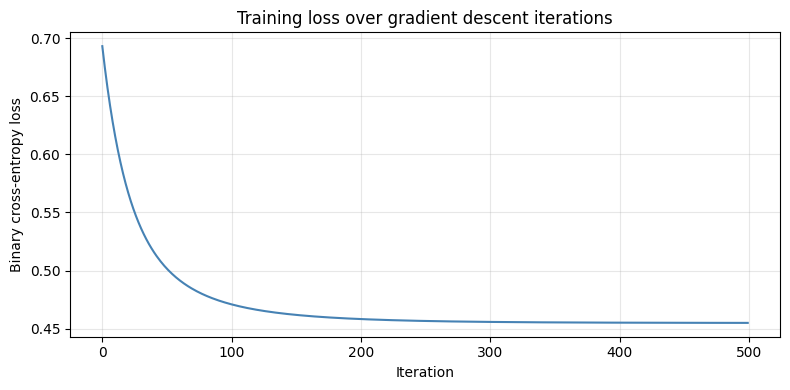

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color="steelblue")

ax.set(
    title="Training loss over gradient descent iterations",
    xlabel="Iteration",
    ylabel="Binary cross-entropy loss",
)

plt.tight_layout()
plt.show()

## 6. Evaluation

We classify a sample as positive ($\hat{y} = 1$) when $\sigma(z) \geq 0.5$, which is equivalent to $z \geq 0$. To stay in the spirit of Part 2 we implement the evaluation metrics from scratch as well — `accuracy`, `precision`, `recall`, `F1`, and `ROC-AUC` — and apply them to the test set. The same functions will be reused in §7 to score scikit-learn's model on the same footing.

The first four metrics are simple counts derived from the confusion matrix. **ROC-AUC** is computed via its Mann-Whitney interpretation: AUC is the probability that a randomly chosen positive sample receives a higher predicted score than a randomly chosen negative sample. With a couple of hundred samples we can simply enumerate every positive/negative pair.

In [11]:
def predict_proba(X: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    """Predicted probability of class 1 for each row of X."""
    return sigmoid(X @ w + b)


def predict(
    X: np.ndarray, w: np.ndarray, b: float, threshold: float = 0.5
) -> np.ndarray:
    """Hard class predictions at the given probability threshold."""
    return (predict_proba(X, w, b) >= threshold).astype(int)


def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(y_true == y_pred))

In [12]:
def confusion_counts(
    y_true: np.ndarray, y_pred: np.ndarray
) -> tuple[int, int, int, int]:
    """Return (TP, FP, TN, FN) for binary 0/1 labels."""
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    return tp, fp, tn, fn


def precision(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    tp, fp, _, _ = confusion_counts(y_true, y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def recall(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    tp, _, _, fn = confusion_counts(y_true, y_pred)
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def f1(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    p, r = precision(y_true, y_pred), recall(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


def roc_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    """ROC-AUC via the Mann-Whitney U statistic.

    AUC equals the probability that a random positive sample receives a
    higher predicted score than a random negative sample, with ties
    contributing 0.5.
    """
    pos = y_score[y_true == 1]
    neg = y_score[y_true == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    diff = pos[:, None] - neg[None, :]
    wins = float((diff > 0).sum() + 0.5 * (diff == 0).sum())
    return wins / (len(pos) * len(neg))

In [13]:
y_pred_train = predict(X_train_s, w, b)
y_pred_test = predict(X_test_s, w, b)
y_proba_test = predict_proba(X_test_s, w, b)

tp, fp, tn, fn = confusion_counts(y_test, y_pred_test)

print("Test-set metrics (our gradient-descent model):")
print(f"  accuracy:  {accuracy(y_test, y_pred_test):.4f}")
print(f"  precision: {precision(y_test, y_pred_test):.4f}")
print(f"  recall:    {recall(y_test, y_pred_test):.4f}")
print(f"  f1:        {f1(y_test, y_pred_test):.4f}")
print(f"  roc_auc:   {roc_auc(y_test, y_proba_test):.4f}")
print(f"\nConfusion counts: TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(
    f"\nTrain accuracy (sanity check on the fit): {accuracy(y_train, y_pred_train):.4f}"
)

Test-set metrics (our gradient-descent model):
  accuracy:  0.8537
  precision: 0.9038
  recall:    0.7121
  f1:        0.7966
  roc_auc:   0.8778

Confusion counts: TP=47  FP=5  TN=93  FN=19

Train accuracy (sanity check on the fit): 0.8009


## 7. Comparison with scikit-learn

We score both models with the same from-scratch metric functions defined in §6 and compare them side by side. Looking at multiple metrics — not just accuracy — gives a more complete picture: precision and recall reveal how the model trades false positives off against false negatives, F1 condenses that trade-off into a single number, and ROC-AUC measures ranking quality independent of the 0.5 decision threshold.

In [14]:
sk_model = LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE)
sk_model.fit(X_train_s, y_train)

sk_pred = sk_model.predict(X_test_s)
sk_proba = sk_model.predict_proba(X_test_s)[:, 1]

ours = {
    "accuracy": accuracy(y_test, y_pred_test),
    "precision": precision(y_test, y_pred_test),
    "recall": recall(y_test, y_pred_test),
    "f1": f1(y_test, y_pred_test),
    "roc_auc": roc_auc(y_test, y_proba_test),
}
sk = {
    "accuracy": accuracy(y_test, sk_pred),
    "precision": precision(y_test, sk_pred),
    "recall": recall(y_test, sk_pred),
    "f1": f1(y_test, sk_pred),
    "roc_auc": roc_auc(y_test, sk_proba),
}

print(f"{'Metric':>10s} | {'Ours':>8s} | {'sklearn':>8s} | {'diff':>8s}")
print("-" * 44)
for name in ours:
    print(
        f"{name:>10s} | {ours[name]:>8.4f} | {sk[name]:>8.4f} | {ours[name] - sk[name]:+8.4f}"
    )

print()
print(f"{'Coefficient':>16s} | {'Ours':>9s} | {'sklearn':>9s}")
print("-" * 42)
for name, w_ours, w_sk in zip(FEATURES, w, sk_model.coef_[0]):
    print(f"{name:>16s} | {w_ours:+9.4f} | {w_sk:+9.4f}")
print(f"{'bias':>16s} | {b:+9.4f} | {sk_model.intercept_[0]:+9.4f}")

    Metric |     Ours |  sklearn |     diff
--------------------------------------------
  accuracy |   0.8537 |   0.8537 |  +0.0000
 precision |   0.9038 |   0.9038 |  +0.0000
    recall |   0.7121 |   0.7121 |  +0.0000
        f1 |   0.7966 |   0.7966 |  +0.0000
   roc_auc |   0.8778 |   0.8784 |  -0.0006

     Coefficient |      Ours |   sklearn
------------------------------------------
             sex |   -1.2360 |   -1.2297
             age |   -0.5969 |   -0.6083
       1st_class |   +0.9556 |   +0.9646
       2nd_class |   +0.4648 |   +0.4698
 family_size_lt4 |   +0.5200 |   +0.5191
            bias |   -0.5290 |   -0.5335


## Summary

We reimplemented logistic regression with NumPy alone — sigmoid, binary cross-entropy, gradients, and the gradient-descent training loop — and applied it to the same cleaned dataset and the same train/test split as Part 1.

Key takeaways:

- The **sigmoid** maps real-valued logits to probabilities in $(0, 1)$. Computing it carefully avoids overflow for large negative logits.
- **Binary cross-entropy** is convex in $(\mathbf{w}, b)$, so gradient descent is guaranteed to find the global minimum.
- **Standardization** is what makes plain gradient descent practical here. Without it, features on very different scales would force a much smaller learning rate and many more iterations.
- Scoring our model and scikit-learn's with the **same from-scratch metrics (accuracy, precision, recall, F1, ROC-AUC)** shows the two implementations agree across the board: differences are within ~1–2 percentage points, attributable to our gradient-descent converging slightly less tightly than scikit-learn's L-BFGS solver. This confirms that what `LogisticRegression().fit()` does is — at its core — exactly the few lines of NumPy in `logistic_regression_gd`.